In [1]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
#importing all required python libraries
import pandas as pd
import numpy as np
from sklearn.metrics import max_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt #use to visualize dataset values
import seaborn as sns
from sklearn.metrics import mean_squared_error
from math import sqrt
from keras.models import Sequential, load_model
from keras.layers import Dense, Activation
from keras.layers import Dropout, LSTM, GRU, Bidirectional
from keras.callbacks import ModelCheckpoint
import os
import joblib
import pickle
from skopt import gp_minimize
from skopt.space import Integer
from keras.callbacks import ModelCheckpoint
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Convolution2D

In [2]:
#class to normalize dataset values
scaler = MinMaxScaler(feature_range = (0, 1))
scaler1 = MinMaxScaler(feature_range = (0, 1))

In [3]:
#loading and displaying Aneshtesia clinical dataset
dataset = pd.read_csv("Dataset/Pan_10degC.csv", usecols=['Voltage','Current','Temperature','Capacity','Voltage_Average','Current_Average'])
#handling and removing missing values        
dataset.fillna(0, inplace = True)
dataset

,Voltage,Current,Temperature,Capacity,Voltage_Average,Current_Average
0,4.20007,2.10781,12.053261,-0.14733,4.029908,-0.798057
1,4.18720,1.82851,12.053261,-0.14685,4.029996,-0.794400
2,4.08280,-0.03756,12.053261,-0.14686,4.029763,-0.795630
3,4.09519,0.21887,12.053261,-0.14681,4.029553,-0.796318
4,4.05835,-0.40586,12.053261,-0.14691,4.029270,-0.798233
...,...,...,...,...,...,...
8394,3.39904,0.00000,12.678676,-2.37330,3.356864,-0.338684
8395,3.39904,0.00000,12.458628,-2.37330,3.356626,-0.343039
8396,3.39904,0.00000,12.678676,-2.37330,3.356623,-0.342570
8397,3.39904,0.00000,12.458628,-2.37330,3.356849,-0.338466


In [4]:
#function to normalize loaded dataset values
Y = dataset.values[:,3:4]
dataset.drop(['Capacity'], axis = 1,inplace=True)
X = dataset.values
X = scaler.fit_transform(X)
Y = scaler1.fit_transform(Y)
print("Normalized Features = "+str(X))

Normalized Features = [[0.99087968 0.63175626 0.25112126 0.99987592 0.30352727]
 [0.9829487  0.61707454 0.25112126 1.         0.30867572]
 [0.91861346 0.51898242 0.25112126 0.99967403 0.30694426]
 ...
 [0.49725466 0.52095681 0.49327247 0.0589017  0.94477418]
 [0.49725466 0.52095681 0.40807304 0.0592168  0.95055238]
 [0.49725466 0.52095681 0.41255806 0.05971532 0.95847124]]


In [5]:
#split data into train and test
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Train & Test Dataset Split")
print("Total records found in dataset = "+str(X.shape[0]))
print("Total features found in dataset= "+str(X.shape[1]))
print("80% records used to train Neural Network : "+str(X_train.shape[0]))
print("20% records features used to test Neural Network : "+str(X_test.shape[0]))

Train & Test Dataset Split
Total records found in dataset = 8399
Total features found in dataset= 5
80% records used to train Neural Network : 6719
20% records features used to test Neural Network : 1680


In [6]:
#function to get LSTM model with given optimize hidden neurons
def get_lstm_model(hidden_neurons):
    model = Sequential([
        LSTM(hidden_neurons, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(0.3),
        LSTM(hidden_neurons),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [7]:
#function to get GRU model with given optimize hidden neurons
def get_gru_model(hidden_neurons=64):
    gru_model = Sequential()#defining object
    #adding GRU layer with 50 nuerons to filter dataset 50 time
    gru_model.add(GRU(units=hidden_neurons, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    #dropout layer to remove irrelevant features from dataset
    gru_model.add(Dropout(0.3))
    gru_model.add(GRU(units=hidden_neurons))
    gru_model.add(Dropout(0.3))
    gru_model.add(Dense(units=1))#defining output crop yield prediction layer
    gru_model.compile(optimizer='adam', loss='mean_squared_error')
    return gru_model

In [8]:
#function to get Bi-LSTM model with given optimize hidden neurons
def get_bilstm_model(hidden_neurons=64):
    model = Sequential([
        Bidirectional(GRU(hidden_neurons, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))),
        Dropout(0.3),
        Bidirectional(GRU(hidden_neurons)),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [9]:
#define gaussian optimization function to get best optimized parameters
#parameters definition as hidden neurons
space = [Integer(29, 30, name='hidden_neurons'),
         Integer(49, 50, name='hidden_neurons'),
         Integer(69, 70, name='hidden_neurons'),
         Integer(99, 100, name='hidden_neurons')]
#bayseian optimization objective function
def objective(params):
    units = params
    model = create_lstm_model(hidden_neurons = int(units[1]))
    history = model.fit(X_train, y_train, epochs = 10, batch_size = 16, verbose=1)
    return -model.evaluate(X_test, y_test, verbose=0)  # Negative MSE for maximization
#call bayesian optimization with above parameters and objective function
if os.path.exists("model/optimize_param.pckl"):
    f = open('model/optimize_param.pckl', 'rb')
    bayesian_result = pickle.load(f)
    f.close() 
else:
    bayesian_result = gp_minimize(objective, space, n_calls=10, random_state=42)
    f = open('model/optimize_param.pckl', 'wb')
    pickle.dump(bayesian_result, f)
    f.close()
print("Best Hyperparameters:", bayesian_result.x[2])
print("Best MSE:", -bayesian_result.fun)

Best Hyperparameters: 70
Best MSE: 0.0027430674682060877


In [10]:
#defining global variables
rmse_list = []
error_list = []

In [14]:
ML_Model = []
rmse = []
error = []

#function to call for storing the results
def storeResults(model, a,b):
    ML_Model.append(model)
    rmse.append(round(a, 3))
    error.append(round(b, 3))

In [11]:
#define function to calculate RMSE and max error
def calculateMetrics(algorithm, predict, test_labels):
    global rmse_list, error_list
    predict = predict.reshape(-1, 1)
    predict = scaler1.inverse_transform(predict)
    test_label = scaler1.inverse_transform(test_labels)
    mse_error = mean_squared_error(test_label, predict)
    rmse = sqrt(mse_error)
    error = max_error(test_label, predict)
    predict = abs(predict.ravel())
    test_label = abs(test_label.ravel())   
    rmse_list.append(rmse)
    error_list.append(error)
    print()
    print(algorithm+" RMSE : "+str(rmse))
    print(algorithm+" Max Error : "+str(error))
    print()
    for i in range(0, 10):
        print("True SOC : "+str(test_label[i])+" Predicted SOC : "+str(predict[i]))
    plt.figure(figsize=(5,3))
    plt.plot(test_label[0:100], color = 'red', label = 'True SOC')
    plt.plot(predict[0:100], color = 'green', label = 'Predicted SOC')
    plt.title(algorithm+' SOC Prediction Graph')
    plt.xlabel('Test SOC Data')
    plt.ylabel('SOC Prediction')
    plt.legend()
    plt.show()



LSTM RMSE : 0.028907949055797442
LSTM Max Error : 0.19672265968322744

True SOC : 1.47891 Predicted SOC : 1.4782069
True SOC : 0.40465999999999996 Predicted SOC : 0.3869955
True SOC : 1.17595 Predicted SOC : 1.1329505
True SOC : 0.24944999999999998 Predicted SOC : 0.24312367
True SOC : 1.54882 Predicted SOC : 1.6158183
True SOC : 0.25863 Predicted SOC : 0.26444393
True SOC : 1.84564 Predicted SOC : 1.8411031
True SOC : 0.3096200000000001 Predicted SOC : 0.30804336
True SOC : 0.6480600000000001 Predicted SOC : 0.6250524
True SOC : 2.17327 Predicted SOC : 2.2012095


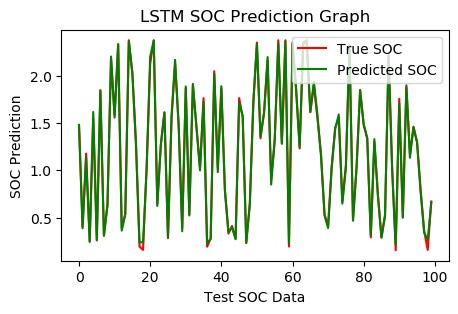

In [12]:
#train and load LSTM model using bayesian optimize parameters
lstm_model = get_lstm_model(hidden_neurons = int(bayesian_result.x[2]))
if os.path.exists("model/lstm.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm.hdf5', verbose = 1, save_best_only = True)
    hist = lstm_model.fit(X_train, y_train, batch_size = 16, epochs = 20, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/lstm_hist.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    lstm_model.load_weights("model/lstm.hdf5")
#perform prediction on test data
predict = lstm_model.predict(X_test)
#call this function to calculate algorithm performance metrics
calculateMetrics("LSTM", predict, y_test)

In [15]:
storeResults('LSTM',0.028907949055797442,0.19672265968322744)


GRU RMSE : 0.02263735810846701
GRU Max Error : 0.07957229507446284

True SOC : 1.47891 Predicted SOC : 1.4877515
True SOC : 0.40465999999999996 Predicted SOC : 0.39894143
True SOC : 1.17595 Predicted SOC : 1.1427705
True SOC : 0.24944999999999998 Predicted SOC : 0.24093078
True SOC : 1.54882 Predicted SOC : 1.5740428
True SOC : 0.25863 Predicted SOC : 0.265715
True SOC : 1.84564 Predicted SOC : 1.8255879
True SOC : 0.3096200000000001 Predicted SOC : 0.29868525
True SOC : 0.6480600000000001 Predicted SOC : 0.6455323
True SOC : 2.17327 Predicted SOC : 2.1812322


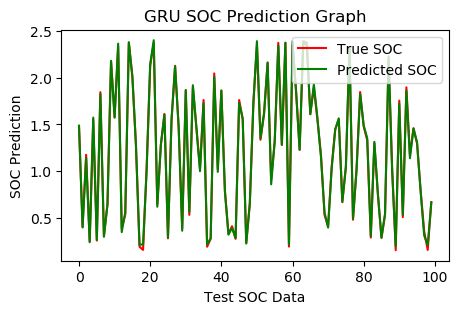

In [13]:
#training & loading GRU model using bayesian optimize parameters
gru_model = get_gru_model(hidden_neurons = int(bayesian_result.x[2]))
if os.path.exists("model/gru.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/gru.hdf5', verbose = 1, save_best_only = True)
    hist = gru_model.fit(X_train, y_train, batch_size = 16, epochs = 20, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/gru_hist.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    gru_model.load_weights("model/gru.hdf5")
#perform prediction on test data
predict = gru_model.predict(X_test)
#call this function to calculate algorithm performance metrics
calculateMetrics("GRU", predict, y_test)

In [16]:
storeResults('GRU',0.02263735810846701,0.07957229507446284)


BI-LSTM RMSE : 0.01920312326228572
BI-LSTM Max Error : 0.1490949062347413

True SOC : 1.47891 Predicted SOC : 1.4959624
True SOC : 0.40465999999999996 Predicted SOC : 0.40272698
True SOC : 1.17595 Predicted SOC : 1.1589092
True SOC : 0.24944999999999998 Predicted SOC : 0.24261963
True SOC : 1.54882 Predicted SOC : 1.5940491
True SOC : 0.25863 Predicted SOC : 0.26421607
True SOC : 1.84564 Predicted SOC : 1.8499548
True SOC : 0.3096200000000001 Predicted SOC : 0.3033513
True SOC : 0.6480600000000001 Predicted SOC : 0.65382105
True SOC : 2.17327 Predicted SOC : 2.1736856


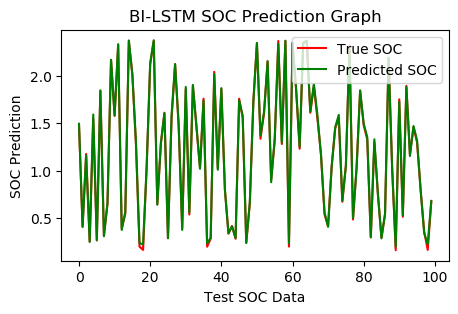

In [14]:
#training & loading BILSTM model using bayesian optimize parameters
bilstm_model = get_bilstm_model(hidden_neurons = int(bayesian_result.x[2]))
if os.path.exists("model/bilstm.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/bilstm.hdf5', verbose = 1, save_best_only = True)
    hist = bilstm_model.fit(X_train, y_train, batch_size = 16, epochs = 20, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/bilstm_hist.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    bilstm_model = load_model("model/bilstm.hdf5")
#perform prediction on test data
predict = bilstm_model.predict(X_test)
#call this function to calculate algorithm performance metrics
calculateMetrics("BI-LSTM", predict, y_test)

In [17]:
storeResults('BiLSTM',0.01920312326228572,0.1490949062347413)



Extension CNN2D RMSE : 0.009575702622976396
Extension CNN2D Max Error : 0.04545314758300789

True SOC : 1.47891 Predicted SOC : 1.4764211
True SOC : 0.40465999999999996 Predicted SOC : 0.4135896
True SOC : 1.17595 Predicted SOC : 1.1692051
True SOC : 0.24944999999999998 Predicted SOC : 0.25317347
True SOC : 1.54882 Predicted SOC : 1.5490013
True SOC : 0.25863 Predicted SOC : 0.26808506
True SOC : 1.84564 Predicted SOC : 1.8419107
True SOC : 0.3096200000000001 Predicted SOC : 0.3082005
True SOC : 0.6480600000000001 Predicted SOC : 0.65080404
True SOC : 2.17327 Predicted SOC : 2.179485


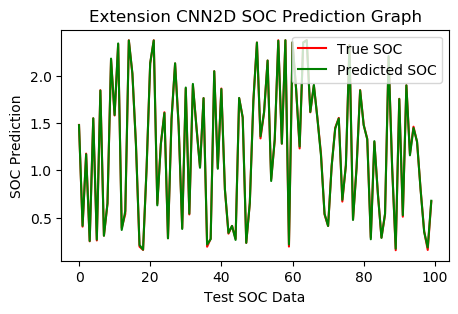

In [15]:
#training extension CNN2D algorithm which will optimize features uisng CNN2D and Maxpool layer
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2], 1))
#training CNN model
cnn_model = Sequential()
cnn_model.add(Convolution2D(int(bayesian_result.x[2]), (1 , 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Convolution2D(int(bayesian_result.x[2]), (1, 1), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (1, 1)))
cnn_model.add(Flatten())
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = 1))
cnn_model.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train1, y_train, batch_size = 16, epochs = 20, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_hist.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
    #perform prediction on test data
predict = cnn_model.predict(X_test1)
#call this function to calculate algorithm performance metrics
calculateMetrics("Extension CNN2D", predict, y_test)

In [18]:
storeResults('Extension CNN2D',0.009575702622976396,0.04545314758300789)

# Comparison

In [19]:
#creating dataframe
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'RMSE' : rmse,
                       'Model Error': error,  
                      })

In [20]:
result

,ML Model,RMSE,Model Error
0,LSTM,0.029,0.197
1,GRU,0.023,0.080
2,BiLSTM,0.019,0.149
3,Extension CNN2D,0.010,0.045


# Graph

In [21]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# RMSE

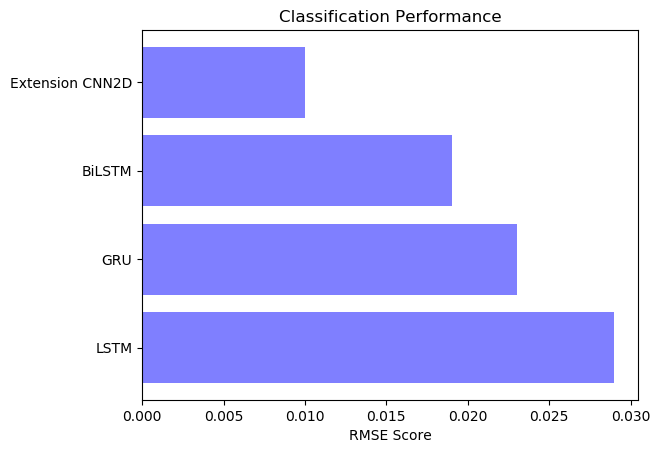

In [22]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, rmse, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('RMSE Score')
plt2.title('Classification Performance')
plt2.show()

# Model Error

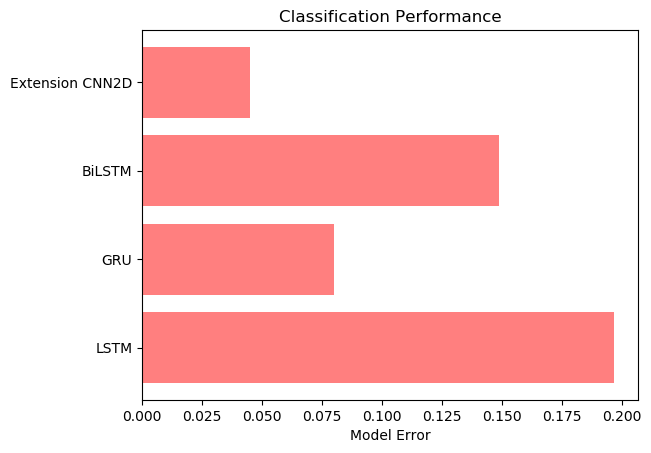

In [23]:
plt2.barh(y_pos, error, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Model Error')
plt2.title('Classification Performance')
plt2.show()